<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [9]:
# carregar o dataset iris e dividir estratificadamente
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

# divisão estratificada garantindo mesma proporção de classes
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamanho treino:", X_treino.shape)
print("Tamanho teste:", X_teste.shape)
print("Distribuição treino:", {i: list(y_treino).count(i) for i in set(y_treino)})
print("Distribuição teste:", {i: list(y_teste).count(i) for i in set(y_teste)})

Tamanho treino: (105, 4)
Tamanho teste: (45, 4)
Distribuição treino: {np.int64(0): 35, np.int64(1): 35, np.int64(2): 35}
Distribuição teste: {np.int64(0): 15, np.int64(1): 15, np.int64(2): 15}


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# treinamento do modelo com parâmetros default
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_treino, y_treino)

# previsões em treino e teste
y_pred_train = clf.predict(X_treino)
y_pred_test = clf.predict(X_teste)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia no treino: {acc_train:.4f}")
print(f"Acurácia no teste:  {acc_test:.4f}")

Acurácia no treino: 1.0000
Acurácia no teste:  0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

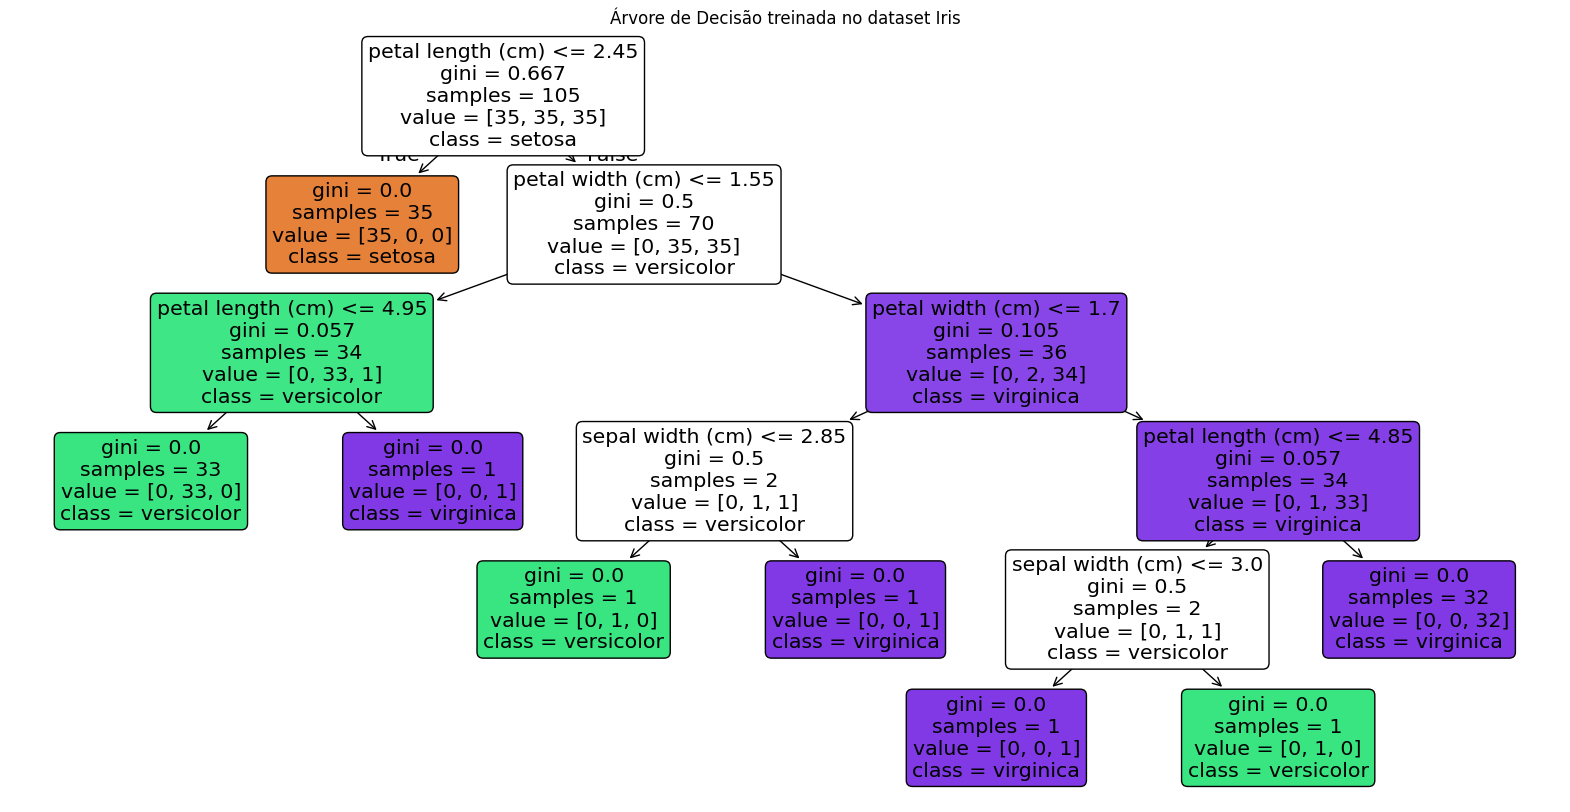

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names, 
          filled=True, 
          rounded=True)
plt.title("Árvore de Decisão treinada no dataset Iris")
plt.show()

tree_depth = clf.get_depth()


**Solução**:

In [16]:
print(f"Profundidade da árvore: {tree_depth}")
print(f"Atributo na raiz (feature index): {clf.tree_.feature[0]}")
print(f"Atributo na raiz (feature name): {iris.feature_names[clf.tree_.feature[0]]}")

Profundidade da árvore: 5
Atributo na raiz (feature index): 2
Atributo na raiz (feature name): petal length (cm)


**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [5]:
import pandas as pd

results = []
for depth in list(range(1,10)) + [None]:
    clf_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_temp.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf_temp.predict(X_train))
    test_acc = accuracy_score(y_test, clf_temp.predict(X_test))
    tree_depth = clf_temp.tree_.max_depth
    n_leaves = clf_temp.tree_.n_leaves
    results.append({
        "max_depth": depth,
        "acc_train": train_acc,
        "acc_test": test_acc,
        "depth": tree_depth,
        "n_leaves": n_leaves,
    })

df_results = pd.DataFrame(results)
print(df_results)

df_results

   max_depth  acc_train  acc_test  depth  n_leaves
0        1.0   0.666667  0.666667      1         2
1        2.0   0.971429  0.888889      2         3
2        3.0   0.980952  0.977778      3         5
3        4.0   0.990476  0.888889      4         7
4        5.0   1.000000  0.933333      5         8
5        6.0   1.000000  0.933333      5         8
6        7.0   1.000000  0.933333      5         8
7        8.0   1.000000  0.933333      5         8
8        9.0   1.000000  0.933333      5         8
9        NaN   1.000000  0.933333      5         8


,max_depth,acc_train,acc_test,depth,n_leaves
0,1.0,0.666667,0.666667,1,2
1,2.0,0.971429,0.888889,2,3
2,3.0,0.980952,0.977778,3,5
3,4.0,0.990476,0.888889,4,7
4,5.0,1.000000,0.933333,5,8
5,6.0,1.000000,0.933333,5,8
6,7.0,1.000000,0.933333,5,8
7,8.0,1.000000,0.933333,5,8
8,9.0,1.000000,0.933333,5,8
9,NaN,1.000000,0.933333,5,8


**Em qual profundidade começa o overfitting?**
Resposta: Overfitting começa quando a profundidade ultrapassa o ponto em que o teste deixa de melhorar (≈3–4 no Iris).

**Por que a árvore consegue 100% no treino quando max_depth=None?**
Resposta: A árvore atinge 100 % no treino com profundidade ilimitada porque consegue particionar os dados até que nenhuma amostra seja classificada incorretamente.





# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [6]:
# comparar critérios gini vs entropy
results_crit = []
for crit in ["gini", "entropy"]:
    clf_c = DecisionTreeClassifier(criterion=crit, random_state=42)
    clf_c.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf_c.predict(X_train))
    test_acc = accuracy_score(y_test, clf_c.predict(X_test))
    depth = clf_c.tree_.max_depth
    results_crit.append({"criterion": crit, "train_acc": train_acc, "test_acc": test_acc, "depth": depth})

import pandas as pd
pd.DataFrame(results_crit)

,criterion,train_acc,test_acc,depth
0,gini,1.0,0.933333,5
1,entropy,1.0,0.888889,6


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [7]:
# investigar impacto de min_samples_leaf
param_values = list(range(1, 11))  # testar de 1 a 10
records = []
for val in param_values:
    clf_h = DecisionTreeClassifier(min_samples_leaf=val, random_state=42)
    clf_h.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf_h.predict(X_train))
    test_acc = accuracy_score(y_test, clf_h.predict(X_test))
    depth = clf_h.tree_.max_depth
    records.append({"min_samples_leaf": val, "train_acc": train_acc,
                    "test_acc": test_acc, "depth": depth})

import pandas as pd
results_hp = pd.DataFrame(records)
print(results_hp)

best = results_hp.loc[results_hp.test_acc.idxmax()]
print("\nMelhor configuração:")
print(best)

   min_samples_leaf  train_acc  test_acc  depth
0                 1   1.000000  0.933333      5
1                 2   0.971429  0.888889      4
2                 3   0.980952  0.844444      4
3                 4   0.971429  0.888889      4
4                 5   0.971429  0.888889      3
5                 6   0.971429  0.888889      3
6                 7   0.971429  0.888889      3
7                 8   0.971429  0.888889      3
8                 9   0.971429  0.888889      3
9                10   0.971429  0.888889      3

Melhor configuração:
min_samples_leaf    1.000000
train_acc           1.000000
test_acc            0.933333
depth               5.000000
Name: 0, dtype: float64
